# Experiment-2

Dataset Preview:
    Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Squa

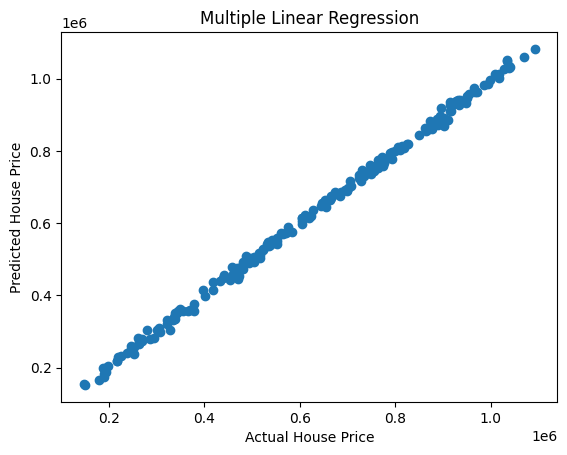


===== RIDGE REGRESSION =====
MAE: 8241.898358133865
MSE: 102486578.62155962
RMSE: 10123.565509323265
R2 Score: 0.998410046605628


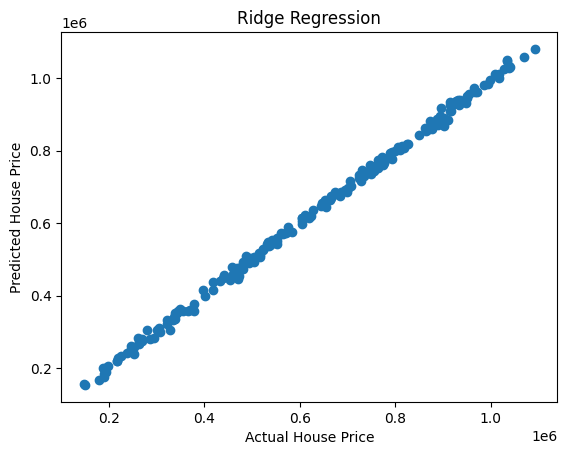


===== LASSO REGRESSION =====
MAE: 8174.585809784338
MSE: 101434824.93285091
RMSE: 10071.48573611912
R2 Score: 0.9984263632723556


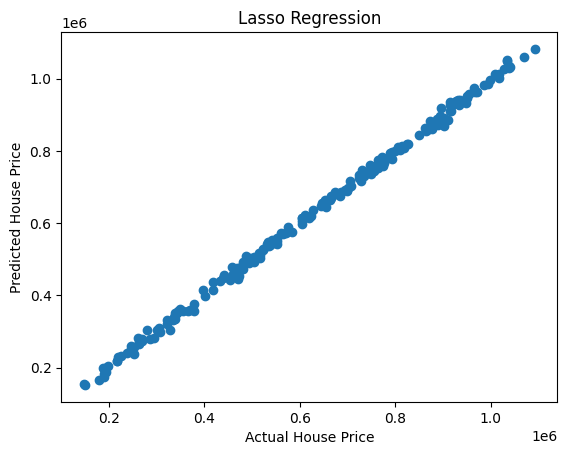

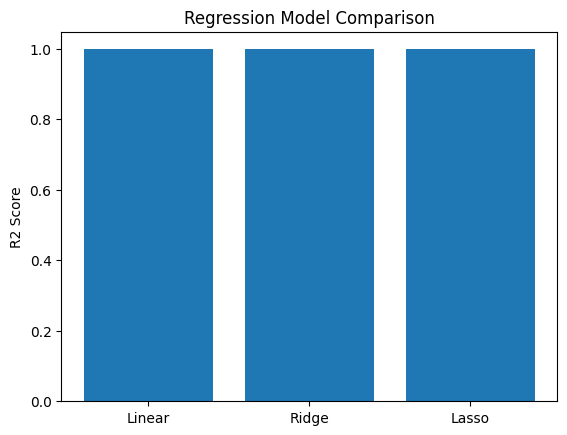


===== HYPERPARAMETER TUNING RESULTS =====
Best Ridge Alpha: {'alpha': 0.001}
Best Lasso Alpha: {'alpha': 10}


In [2]:
# =====================================
# IMPORT LIBRARIES
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =====================================
# LOAD DATASET
# =====================================
# Upload home_value_insights.csv before running

df = pd.read_csv("/content/sample_data/house_price_regression_dataset.csv")
print("Dataset Preview:\n", df.head())


# =====================================
# DATA CHECK & CLEANING
# =====================================
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()


# =====================================
# FEATURE & TARGET SPLIT
# =====================================
X = df.drop(columns=["House_Price"])
y = df["House_Price"]


# =====================================
# FEATURE SCALING
# =====================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =====================================
# TRAIN-TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# =====================================
# MULTIPLE LINEAR REGRESSION
# =====================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n===== MULTIPLE LINEAR REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Multiple Linear Regression")
plt.show()


# =====================================
# RIDGE REGRESSION
# =====================================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("\n===== RIDGE REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Ridge Regression")
plt.show()


# =====================================
# LASSO REGRESSION
# =====================================
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("\n===== LASSO REGRESSION =====")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

plt.figure()
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Lasso Regression")
plt.show()


# =====================================
# MODEL COMPARISON GRAPH
# =====================================
models = ["Linear", "Ridge", "Lasso"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.figure()
plt.bar(models, r2_scores)
plt.ylabel("R2 Score")
plt.title("Regression Model Comparison")
plt.show()


# =====================================
# HYPERPARAMETER TUNING
# =====================================
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5)
ridge_grid.fit(X_train, y_train)

lasso_grid = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_grid.fit(X_train, y_train)

print("\n===== HYPERPARAMETER TUNING RESULTS =====")
print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Best Lasso Alpha:", lasso_grid.best_params_)